# Evalvaluate Predictions

In [1]:
%load_ext autoreload
%autoreload 2
import os
import polars as pl
import numpy as np
from deeptan.utils.metrics import MetricsDictMaker

/home/wuch/miniforge3/envs/t1/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Computing metrics

In [2]:
path_home_deeptan = "/mnt/hdd2/homext/wuch/xn2p"
path_predictions = os.path.join(path_home_deeptan, "run", "predict", "deeptan")
path_raw_df = os.path.join(path_home_deeptan, "data", "raw_df")

### snrna_6tissues_Epidermal.balanced.full.nmicg6

In [3]:
dataset = "snrna_6tissues_Epidermal.balanced.full.nmicg6"
# --threcv 7.0 --thremi 0.1 --minwin 0.02 --maxwin 0.3 --stepwin 0.02 --stepsli 0.01
path_true = os.path.join(path_raw_df, "snRNA", "ath_snrna_6tissues_Epidermal.balanced.split_full")
path_orig_h5ad = os.path.join(path_true, "origin.h5ad")

metricsmaker = MetricsDictMaker(os.path.join(path_predictions, dataset), path_true, True, path_orig_h5ad)
metricsmaker.load_predictions()
metricsmaker.load_true()


Found file📄 preds+seed_42+multitask+tst.h5 with task🎯 multitask and split🍰 tst.


In [4]:
obs_names_pred = metricsmaker._read_batch_in_h5(metricsmaker.fnames[0], "obs_name")
obs_names_pred_list = [i.decode('utf-8') for i in obs_names_pred]
print(len(obs_names_pred_list))
print(obs_names_pred_list)

1714
['ATTCCATTCCGCGATG-1_1-seed', 'TCAGTCCAGGGCAATC-1_5-silique', 'TAGGGTTTCTAGCCTC-1_2-rosette', 'CAATGACTCGACATAC-1_2-seed', 'ATCACAGGTTCGTGCG-1_2-silique', 'AATCACGGTATTTCTC-1_3-silique', 'GACATCATCTGGCCAG-1_5-rosette', 'TGCGGCAAGCTGTTCA-1_5-seedling', 'GCATGATCAGCTGTGC-1_2-seedling', 'GCCATGGTCACCCTCA-1_3-flower', 'GCACTAATCTGCACCT-1_3-stem', 'GTTACCCTCACTTATC-1_3-flower', 'GTGTTAGCAGACGATG-1_1-flower', 'TGGTGATAGTGCTACT-1_3-seed', 'GTTTACTAGCGTATAA-1_5-silique', 'CAGCCAGTCACTGGGC-1_4-seed', 'CTTCTAATCAGATGCT-1_2-rosette', 'AAGCATCCAATGTCAC-1_1-seed', 'AGCCAGCCAATAGTAG-1_2-stem', 'GGGAGTAAGCTAGAGC-1_4-seedling', 'GGTGTTAAGTAGACCG-1_2-flower', 'AGGTTACGTTTATGCG-1_2-flower', 'AAGAACATCCACATAG-1_4-flower', 'CACGTTCAGCTAGAAT-1_4-seed', 'CTCTCGATCGAGCCAC-1_6-rosette', 'TCTACCGAGATTGTGA-1_4-seed', 'GGAGGTACACGTGTGC-1_5-silique', 'TCCGATCGTTCTCTAT-1_6-silique', 'CGGGTCACACAAGTTC-1_6-seedling', 'TCCTAATCATGCAGCC-1_5-seedling', 'AGCGTATGTTGTAAAG-1_1-seed', 'AGTAACCGTCGTCTCT-1_2-stem', 'CTG

In [5]:
if obs_names_pred_list == metricsmaker.metrics_dict["true"]["seed_42_tst"]["obs_names"]:
    print("list1 和 list2 的内容和顺序完全相同")
else:
    print("list1 和 list2 的内容和顺序不完全相同")

if sorted(obs_names_pred_list) == sorted(metricsmaker.metrics_dict["true"]["seed_42_tst"]["obs_names"]):
    print("list1 和 list2 的内容和顺序完全相同")
else:
    print("list1 和 list2 的内容和顺序不完全相同")

list1 和 list2 的内容和顺序不完全相同
list1 和 list2 的内容和顺序完全相同


### Write to CSV

In [6]:
# metricsmaker.metrics_dict["summary_recon"].write_csv(f"result.{dataset}.summary_recon.csv")
# metricsmaker.metrics_dict["summary_label"].write_csv(f"result.{dataset}.summary_label.csv")
# metricsmaker.metrics_dict["summary_clustering"].write_csv(f"result.{dataset}.summary_clustering.csv")

## Plot

In [7]:
from deeptan.utils.metrics import pacmap_plot, pacmap_plot_data

%config InlineBackend.figure_format = 'retina'
%config InlineBackend.figure_dpi = 300

### Plot PaCMAP

In [8]:
_seed = 42
_split = "tst"

_tasks = ["multitask"]
# _tasks_text = ["Multitask"]

In [9]:
true_features, pred_features, g_embs, y_true_text, ys_pred_text = pacmap_plot_data(metricsmaker, _tasks, _split, _seed)

print(true_features.shape)
print(g_embs["multitask"].shape)
print(pred_features["multitask"].shape)

Unique cell types:  ['flower_Epidermal', 'rosette_Epidermal', 'seed_Epidermal', 'seedling_Epidermal', 'silique_Epidermal', 'stem_Epidermal', 'unknown']
(1714, 2341)
(1714, 512)
(1714, 2341)


#### Now we can plot

/home/wuch/miniforge3/envs/t1/lib/python3.10/site-packages/legacy_api_wrap/__init__.py:82: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)
/home/wuch/prjs/git_nwafu/DeepTAN/src/deeptan/utils/metrics.py:755: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(_adata, resolution=resolution, key_added=key_leiden)



Task: multitask


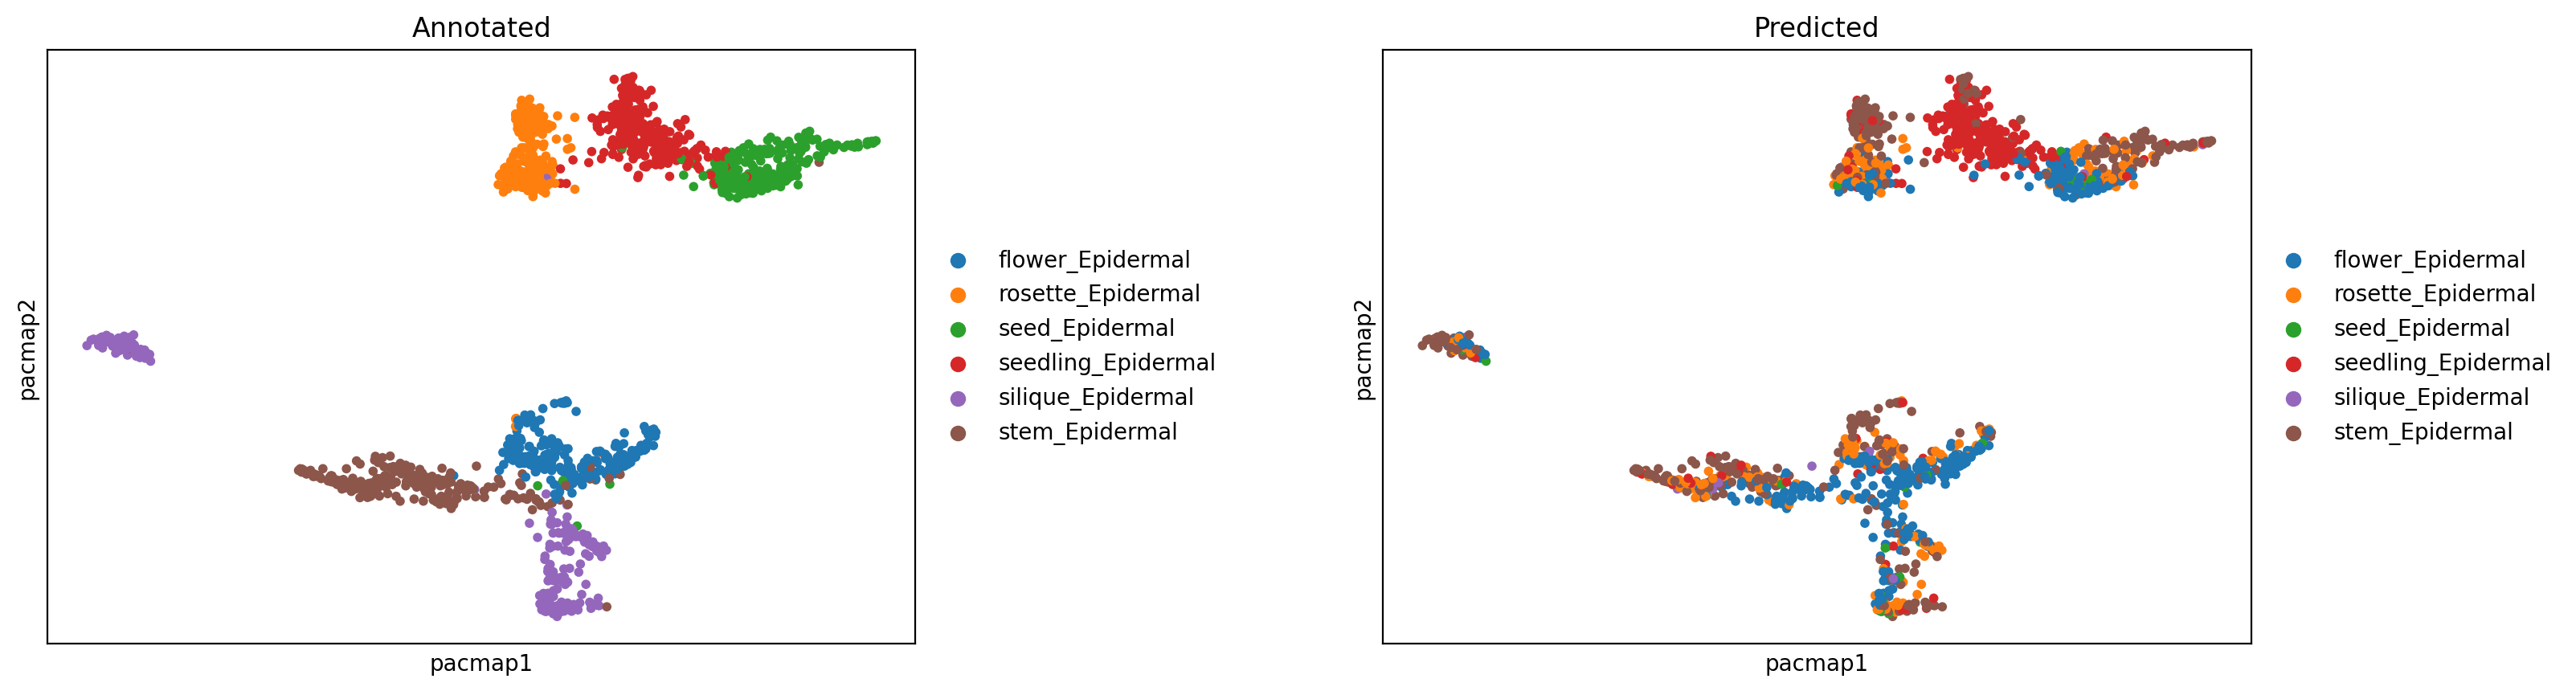

Input data contains invalid values (<= 0 or NaN).


/home/wuch/miniforge3/envs/t1/lib/python3.10/site-packages/legacy_api_wrap/__init__.py:82: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)


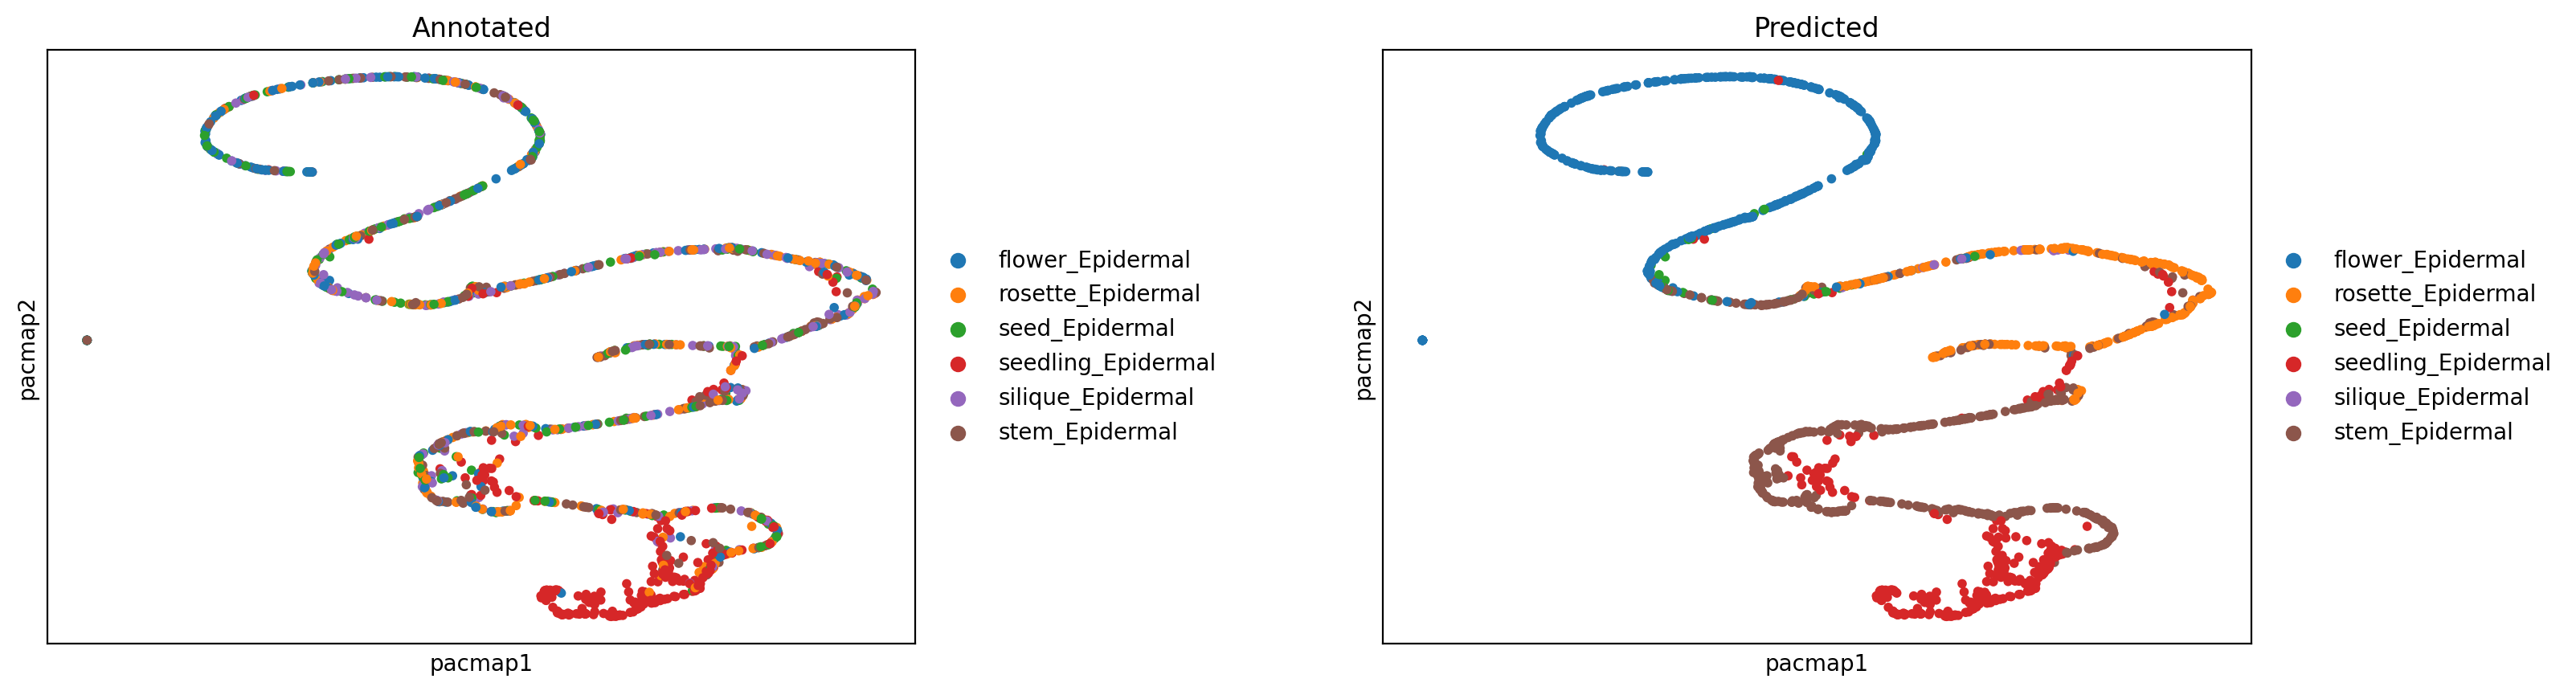

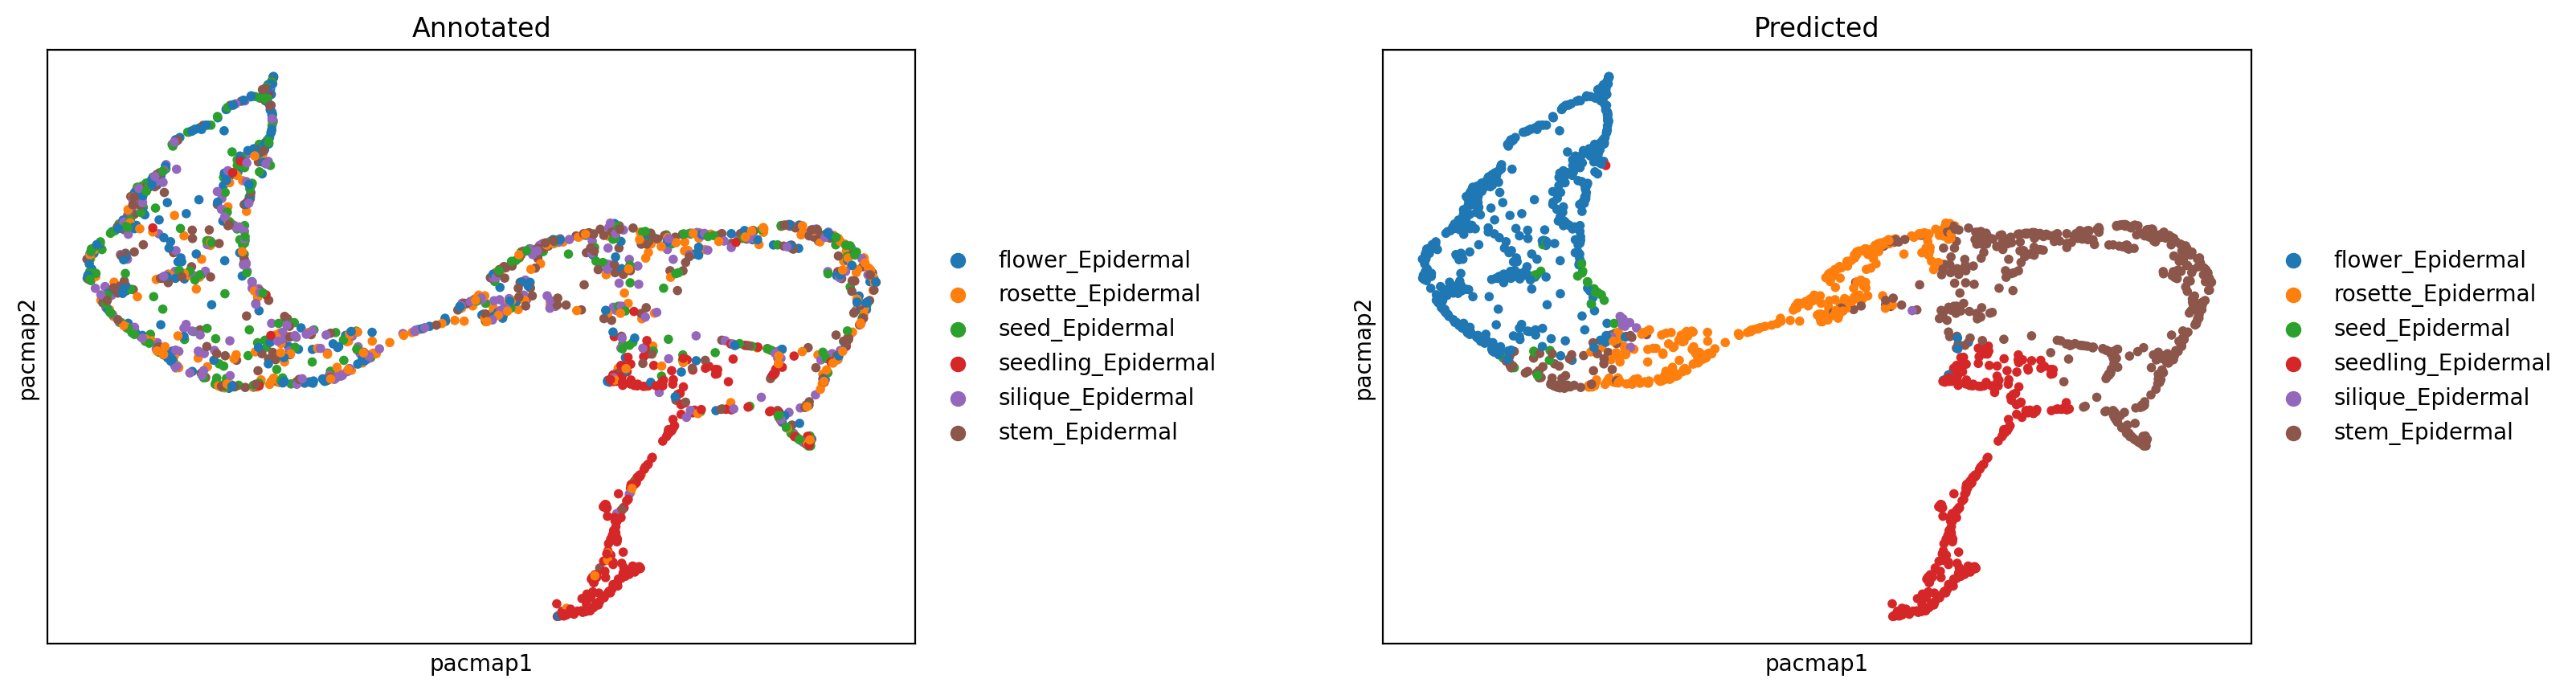

In [10]:
pacmap_plot(true_features, pred_features, g_embs, y_true_text, ys_pred_text)